Mounted at /content/drive
(2436, 224, 224, 3)
(2436,)
(1244, 224, 224, 3)
(1244,)


Text(0.5, 1.0, '0')

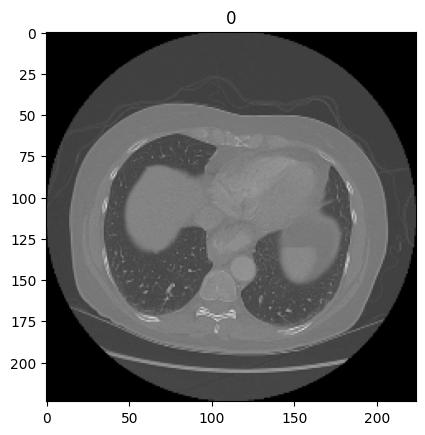

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.applications import VGG16
from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.callbacks import  ReduceLROnPlateau
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
drive.mount('/content/drive')

x_train = np.load("/content/drive/MyDrive/MedScanProject/Lung224trainX.npy")
y_train = np.load("/content/drive/MyDrive/MedScanProject/Lung224trainY.npy")
x_test= np.load("/content/drive/MyDrive/MedScanProject/Lung224testX.npy")
y_test = np.load("/content/drive/MyDrive/MedScanProject/Lung224testY.npy")

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
plt.imshow(x_train[0])
plt.title(f"{y_train[0]}")

In [2]:
data_gen = ImageDataGenerator(rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')
data_gen.fit(x_train)
reduce_lr = ReduceLROnPlateau(reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # metric to watch
    factor=0.2,           # new_lr = lr * factor
    patience=5,           # epochs with no improvement before reducing
    min_lr=1e-6,          # lower bound for learning rate
    verbose=1             # logs the change
))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 606ms/step - accuracy: 0.6361 - loss: 1.8906 - val_accuracy: 0.7773 - val_loss: 0.4747 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.7808 - loss: 0.4803 - val_accuracy: 0.8042 - val_loss: 0.4611 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - accuracy: 0.7997 - loss: 0.4285 - val_accuracy: 0.7819 - val_loss: 0.4489 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.8111 - loss: 0.4051 - val_accuracy: 0.7784 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 260ms/step - accuracy: 0.8269 - loss: 0.3749 - val_accuracy: 0.7948 - val_loss: 0.5306 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 269ms/step - accuracy: 0.8200 - loss: 0.3826 - val_accuracy: 0.8019 - val_loss: 0.4416 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━

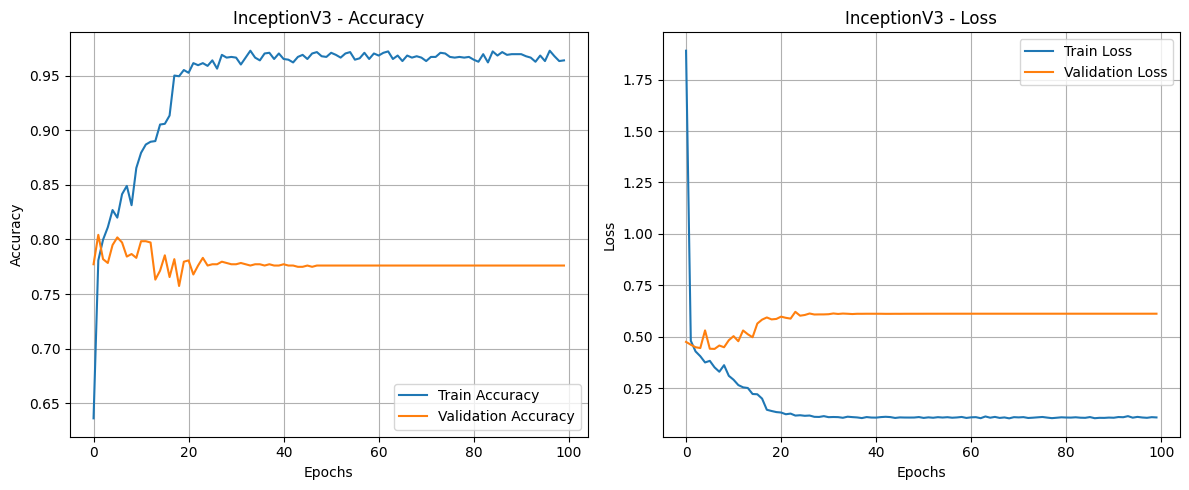

In [3]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
  layer.trainable = False
x = Flatten()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(len(np.unique(y_train)), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=["accuracy"])
history = model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.35,
    callbacks=[reduce_lr]
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
test_accuracy *= 100
print(f'Test Accuracy: {test_accuracy:.2f}% | Test Loss: {test_loss:.4f}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
model.save("/content/drive/MyDrive/MedScanProject/LungCancer(A78L1).keras")
